# Scapy 

In [1]:
from scapy.all import * 
import pandas as pd 
import numpy as np
import binascii 
import seaborn as sns
sns.set(color_codes=True)
%matplotlib inline

## Sniffing de tráfico

In [2]:

num_of_packets_to_sniff = 10
pcap = sniff(count=num_of_packets_to_sniff)

# rdpcap returns packet list
## packetlist object can be enumerated
print(type(pcap))
print(len(pcap))
print(pcap)
pcap[0]

<class 'scapy.plist.PacketList'>
10
<Sniffed: TCP:2 UDP:8 ICMP:0 Other:0>


<Ether  dst=ff:ff:ff:ff:ff:ff src=c0:25:67:8c:47:f0 type=IPv4 |<IP  version=4 ihl=5 tos=0x0 len=162 id=44418 flags= frag=0 ttl=64 proto=udp chksum=0xccc9 src=0.0.0.0 dst=255.255.255.255 |<UDP  sport=11113 dport=11111 len=142 chksum=0xa2ff |<Raw  load=b'\xf1\xf2\xf3\xf4\xd9\xd7@\x7f\xed\x87\x8eb\x01\x06Vektor\x02\rAEFME904U1-v1\x03\x01\x01\n\x06\xc0%g\x8cG\xf0\x04\x04\x01\x05\xa8\xc0\x05\x01\x00\x06\x01\x01\x07\x01\x00\x08\x044\xc3\x02\x00\t\x04\x9e\xd5\xe4i\r\x12904U12021012001235\x0b\x08SpaceOne\x0c\x100210119170404615\x0e\x01\x02\x10\x08Q\xb3^\xac{\x01\x00\x00' |>>>>

## Leer un PCAP de Wireshark

In [3]:
pcap = rdpcap("analisis_paquetes.pcap")

## Otras funciones

In [4]:
# high-level functions are already coded
lsc()

IPID_count            : Identify IP id values classes in a list of packets
arp_mitm              : ARP MitM: poison 2 target's ARP cache
arpcachepoison        : Poison targets' ARP cache
arping                : Send ARP who-has requests to determine which hosts are up::
arpleak               : Exploit ARP leak flaws, like NetBSD-SA2017-002.
bind_layers           : Bind 2 layers on some specific fields' values.
bridge_and_sniff      : Forward traffic between interfaces if1 and if2, sniff and return
chexdump              : Build a per byte hexadecimal representation
computeNIGroupAddr    : Compute the NI group Address. Can take a FQDN as input parameter
connect_from_ip       : Open a TCP socket to a host:port while spoofing another IP.
corrupt_bits          : Flip a given percentage (at least one bit) or number of bits
corrupt_bytes         : Corrupt a given percentage (at least one byte) or number of bytes
dclocator             : Perform a DC Locator as per [MS-ADTS] sect 6.3.6 or RFC41

### Recordemos las capas: Física/Enlace -> Red/IP -> Transporte

In [5]:
ethernet_frame = pcap[0]
ip_packet = ethernet_frame.payload
segment = ip_packet.payload
data = segment.payload # Retrieve payload that comes after layer 4

In [6]:
# Understanding the object types in scapy
print(type(ethernet_frame))
print(type(ip_packet))
print(type(segment))

<class 'scapy.layers.l2.Ether'>
<class 'scapy.layers.inet.IP'>
<class 'scapy.layers.inet.UDP'>


In [7]:
hexdump(pcap[0])

0000  80 37 73 96 9B DB 88 E9 FE 6A 92 52 08 00 45 00  .7s......j.R..E.
0010  03 C1 00 01 00 00 40 11 52 E6 0A 01 0A 35 54 36  ......@.R....5T6
0020  16 21 00 35 00 35 03 AD F6 0E 00 0C 01 00 00 01  .!.5.5..........
0030  00 00 00 00 00 00 06 67 6F 6F 67 6C 65 03 63 6F  .......google.co
0040  6D 00 00 1C 00 01 EF BF BD 50 4E 47 0D 0A 1A 0A  m........PNG....
0050  00 00 00 0D 49 48 44 52 00 00 01 62 00 00 00 EF  ....IHDR...b....
0060  BF BD 08 06 00 00 00 28 EF BF BD 54 52 00 00 3A  .......(...TR..:
0070  EF BF BD 49 44 41 54 78 EF BF BD EF BF BD 09 7C  ...IDATx.......|
0080  54 EF BF BD EF BF BD EF BF BD EF BF BD EF BF BD  T...............
0090  3B 4B 12 08 3B 08 EF BF BD 0A 45 EF BF BD EF BF  ;K..;.....E.....
00a0  BD 24 19 EF BF BD EF BF BD 5A 69 DF AA 2D EF BF  .$.......Zi..-..
00b0  BD 3B 4E 32 EF BF BD EF BF BD 56 EF BF BD 56 EF  .;N2......V...V.
00c0  BF BD 61 EF BF BD 5A 11 21 EF BF BD EF BF BD 01  ..a...Z.!.......
00d0  DC BB 69 6B 5B EF BF BD 2E 6F 6B EF BF BD 65 EF  ..ik[....

In [8]:
ls(pcap[0])

dst        : DestMACField                        = '80:37:73:96:9b:db' ('None')
src        : SourceMACField                      = '88:e9:fe:6a:92:52' ('None')
type       : XShortEnumField                     = 2048            ('36864')
--
version    : BitField  (4 bits)                  = 4               ('4')
ihl        : BitField  (4 bits)                  = 5               ('None')
tos        : XByteField                          = 0               ('0')
len        : ShortField                          = 961             ('None')
id         : ShortField                          = 1               ('1')
flags      : FlagsField                          = <Flag 0 ()>     ('<Flag 0 ()>')
frag       : BitField  (13 bits)                 = 0               ('0')
ttl        : ByteField                           = 64              ('64')
proto      : ByteEnumField                       = 17              ('0')
chksum     : XShortField                         = 21222           ('None')
src       

In [9]:
pcap[0].summary()

"Ether / IP / UDP / DNS Qry b'google.com.' / Raw"

## Convertir PCAP a un DataFrame

Scapy es una librería muy versatil, pero sus estructuras de datos no son tan fáciles de manipular como un data frame

In [10]:
# Collect field names from IP/TCP/UDP (These will be columns in DF)
ip_fields = [field.name for field in IP().fields_desc]
tcp_fields = [field.name for field in TCP().fields_desc]
udp_fields = [field.name for field in UDP().fields_desc]

dataframe_fields = ip_fields + ['time'] + tcp_fields + ['payload','payload_raw','payload_hex']

# Create blank DataFrame
df = pd.DataFrame(columns=dataframe_fields)
for packet in pcap[IP]:
    # Field array for each row of DataFrame
    field_values = []
    # Add all IP fields to dataframe
    for field in ip_fields:
        if field == 'options':
            # Retrieving number of options defined in IP Header
            field_values.append(len(packet[IP].fields[field]))
        else:
            field_values.append(packet[IP].fields[field])
    
    field_values.append(packet.time)
    
    layer_type = type(packet[IP].payload)
    for field in tcp_fields:
        try:
            if field == 'options':
                field_values.append(len(packet[layer_type].fields[field]))
            else:
                field_values.append(packet[layer_type].fields[field])
        except:
            field_values.append(None)
    
    # Append payload
    field_values.append(len(packet[layer_type].payload))
    field_values.append(packet[layer_type].payload.original)
    field_values.append(binascii.hexlify(packet[layer_type].payload.original))
    # Add row to DF
    df_append = pd.DataFrame([field_values], columns=dataframe_fields)
    df = pd.concat([df, df_append], axis=0)

# Reset Index
df = df.reset_index()
# Drop old index column
df = df.drop(columns="index")

In [11]:
df.head()

,version,ihl,tos,len,id,flags,frag,ttl,proto,chksum,...,dataofs,reserved,flags,window,chksum,urgptr,options,payload,payload_raw,payload_hex
0,4,5,0,961,1,,0,64,17,21222,...,None,None,None,None,62990,None,None,933,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...
1,4,5,32,84,58919,,0,122,17,13836,...,None,None,None,None,65061,None,None,56,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...,b'000c8180000100010000000006676f6f676c6503636f...
2,4,5,0,975,1,,0,64,17,21208,...,None,None,None,None,36378,None,None,947,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...
3,4,5,32,84,59493,,0,122,17,13262,...,None,None,None,None,65063,None,None,56,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...,b'000c8180000100010000000006676f6f676c6503636f...
4,4,5,0,1012,1,,0,64,17,21171,...,None,None,None,None,63846,None,None,984,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...


In [12]:
df.shape

(62, 28)

In [13]:
df

,version,ihl,tos,len,id,flags,frag,ttl,proto,chksum,...,dataofs,reserved,flags,window,chksum,urgptr,options,payload,payload_raw,payload_hex
0,4,5,0,961,1,,0,64,17,21222,...,None,None,None,None,62990,None,None,933,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...
1,4,5,32,84,58919,,0,122,17,13836,...,None,None,None,None,65061,None,None,56,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...,b'000c8180000100010000000006676f6f676c6503636f...
2,4,5,0,975,1,,0,64,17,21208,...,None,None,None,None,36378,None,None,947,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...
3,4,5,32,84,59493,,0,122,17,13262,...,None,None,None,None,65063,None,None,56,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...,b'000c8180000100010000000006676f6f676c6503636f...
4,4,5,0,1012,1,,0,64,17,21171,...,None,None,None,None,63846,None,None,984,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,4,5,32,84,8744,,0,122,17,64011,...,None,None,None,None,65088,None,None,56,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...,b'000c8180000100010000000006676f6f676c6503636f...
58,4,5,0,969,1,,0,64,17,21214,...,None,None,None,None,671,None,None,941,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...
59,4,5,32,84,9344,,0,122,17,63411,...,None,None,None,None,65089,None,None,56,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...,b'000c8180000100010000000006676f6f676c6503636f...
60,4,5,0,588,1,,0,64,17,21595,...,None,None,None,None,54406,None,None,560,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...


In [14]:
pcap[IP]

<IP from analisis_paquetes.pcap: TCP:0 UDP:62 ICMP:0 Other:0>

In [15]:
print(len(pcap))


62


## Estadísticas

In [16]:
# Top Source Adddress
# Para datos categóricos, describe devuelve conteo, valores distintos, valor más frecuente (top) y su frecuencia
print("# Top Source Address")
print(df['src'].describe(),'\n\n') 

frequent_address = df['src'].describe()['top']

# Who is the top address speaking to
print("# Who is Top Address Speaking to?")
print(df[df['src'] == frequent_address]['dst'].unique(),"\n\n")



# Top Source Address
count             62
unique             3
top       10.1.10.53
freq              31
Name: src, dtype: object 


# Who is Top Address Speaking to?
['84.54.22.33' '75.75.75.75'] 




In [17]:
# Unique Source Addresses
print("Unique Source Addresses")
print(df['src'].unique())

print()

# Unique Destination Addresses
print("Unique Destination Addresses")
print(df['dst'].unique())

Unique Source Addresses
['10.1.10.53' '84.54.22.33' '75.75.75.75']

Unique Destination Addresses
['84.54.22.33' '10.1.10.53' '75.75.75.75']


<Axes: title={'center': 'Addresses Sending Payloads'}, ylabel='src'>

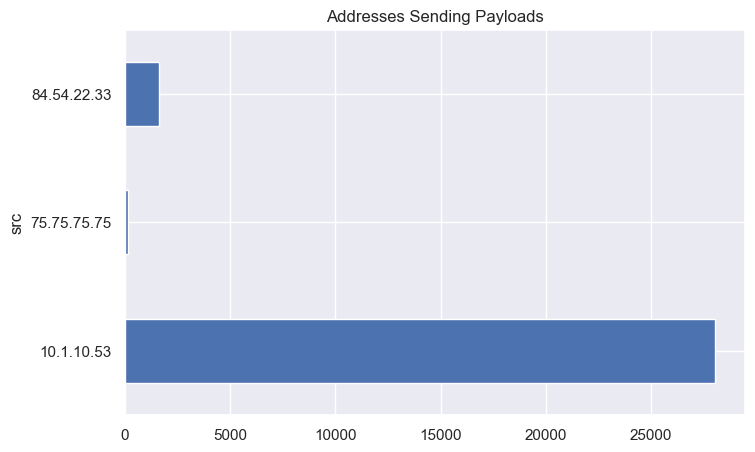

In [18]:
# Group by Source Address and Payload Sum
source_addresses = df.groupby("src")['payload'].sum()
source_addresses.plot(kind='barh',title="Addresses Sending Payloads",figsize=(8,5))

In [19]:
features = df.columns.tolist()
features

['version',
 'ihl',
 'tos',
 'len',
 'id',
 'flags',
 'frag',
 'ttl',
 'proto',
 'chksum',
 'src',
 'dst',
 'options',
 'time',
 'sport',
 'dport',
 'seq',
 'ack',
 'dataofs',
 'reserved',
 'flags',
 'window',
 'chksum',
 'urgptr',
 'options',
 'payload',
 'payload_raw',
 'payload_hex']

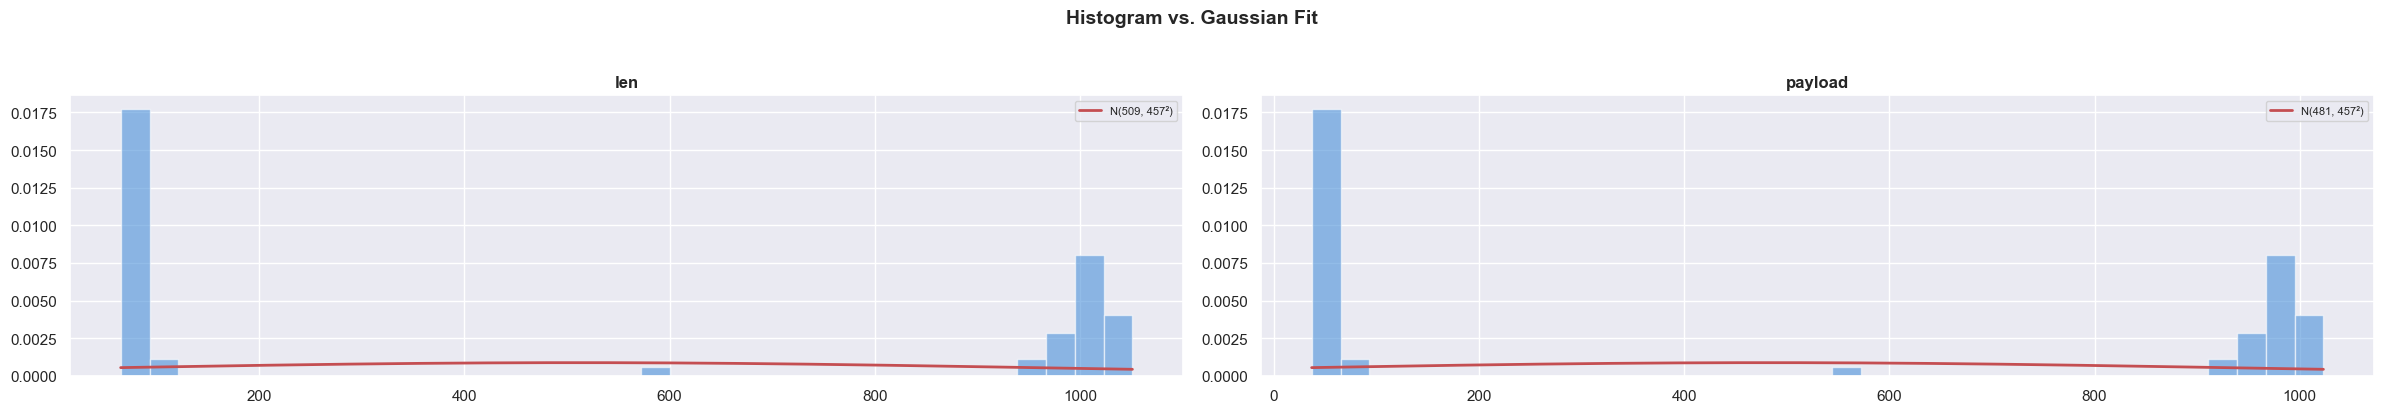

In [20]:
import matplotlib.pyplot as plt
from scipy import stats


important_features = ['len', 'payload']


# ---- Panel 1: Histograms with Gaussian fit overlay ----
fig, axes = plt.subplots(1, 2, figsize=(24, 4))

for ax, feat in zip(axes, important_features):
    data = df[feat].values
    ax.hist(data, bins=35, density=True, alpha=0.6, color='#4A90D9', edgecolor='white')

    # Overlay the best-fit Gaussian curve
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label=f'N({mu:.0f}, {sigma:.0f}²)')

    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Histogram vs. Gaussian Fit',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## Parte 1 - Análisis de paquetes

### Testeo de la herramienta

In [27]:
# 1. Capturar 10 paquetes: imprimir tipo de objeto, longitud y contenido
pcap_test = sniff(count=10)
print(f"Tipo de objeto: {type(pcap_test)}")
print(f"Número de paquetes capturados: {len(pcap_test)}")
print("\n--- Contenido de los 10 paquetes ---")
for i, pkt in enumerate(pcap_test):
    print(f"\nPaquete {i}: tipo={type(pkt).__name__}, longitud={len(pkt)} bytes")
    print(f"  {pkt.summary()}")

Tipo de objeto: <class 'scapy.plist.PacketList'>
Número de paquetes capturados: 10

--- Contenido de los 10 paquetes ---

Paquete 0: tipo=Ether, longitud=157 bytes
  Ether / Dot1Q / IP / TCP 40.79.173.40:https > 192.168.5.66:21251 PA / Raw

Paquete 1: tipo=Ether, longitud=491 bytes
  Ether / IP / TCP 192.168.5.66:21251 > 40.79.173.40:https PA / Raw

Paquete 2: tipo=Ether, longitud=176 bytes
  Ether / IP / UDP 0.0.0.0:11113 > 255.255.255.255:11111 / Raw

Paquete 3: tipo=Ether, longitud=60 bytes
  Ether / Dot1Q / IP / TCP 40.79.173.40:https > 192.168.5.66:21251 PA / Raw

Paquete 4: tipo=Ether, longitud=4438 bytes
  Ether / Dot1Q / IP / TCP 40.79.173.40:https > 192.168.5.66:21251 A / Raw

Paquete 5: tipo=Ether, longitud=66 bytes
  Ether / IP / TCP 192.168.5.66:21251 > 40.79.173.40:https A

Paquete 6: tipo=Ether, longitud=54 bytes
  Ether / IP / TCP 192.168.5.66:21251 > 40.79.173.40:https A

Paquete 7: tipo=Ether, longitud=2241 bytes
  Ether / IP / TCP 192.168.5.66:21251 > 40.79.173.40:htt

In [32]:
# 2. Mostrar columnas: Src Address, Dst Address, Src Port, Dst Port
print("\n Tabla: Src Address, Dst Address, Src Port, Dst Port ")
rows = []
for pkt in pcap_test:
    if IP in pkt:
        src_port = pkt[TCP].sport if TCP in pkt else (pkt[UDP].sport if UDP in pkt else None)
        dst_port = pkt[TCP].dport if TCP in pkt else (pkt[UDP].dport if UDP in pkt else None)
        rows.append({ 'Src Address': pkt[IP].src, 'Dst Address': pkt[IP].dst, 'Src Port': src_port, 'Dst Port': dst_port })
display(pd.DataFrame(rows))


 Tabla: Src Address, Dst Address, Src Port, Dst Port 


,Src Address,Dst Address,Src Port,Dst Port
0,40.79.173.40,192.168.5.66,443,21251
1,192.168.5.66,40.79.173.40,21251,443
2,0.0.0.0,255.255.255.255,11113,11111
3,40.79.173.40,192.168.5.66,443,21251
4,40.79.173.40,192.168.5.66,443,21251
5,192.168.5.66,40.79.173.40,21251,443
6,192.168.5.66,40.79.173.40,21251,443
7,192.168.5.66,40.79.173.40,21251,443
8,40.79.173.40,192.168.5.66,443,21251
9,40.79.173.40,192.168.5.66,443,21251


## Estadísticas y detección con Z-Score

### 3. Estadísticas básicas

In [41]:
# a. IP origen más frecuente
top_src = df['src'].value_counts().idxmax()
print(f"a. IP origen más frecuente:  {top_src}  ({df['src'].value_counts().max()} paquetes)")

# b. IP destino más frecuente
top_dst = df['dst'].value_counts().idxmax()
print(f"b. IP destino más frecuente: {top_dst}  ({df['dst'].value_counts().max()} paquetes)")

# c. ¿A qué IPs se comunica la IP del inciso a?
ips_a_comunica = df[df['src'] == top_src]['dst'].unique()
print(f"\nc. IPs a las que se comunica {top_src}:")
for ip in ips_a_comunica:
    print(f"   - {ip}")

# d. ¿A qué puertos destino se comunica la IP del inciso a?
puertos_dst_a = df[df['src'] == top_src]['dport'].dropna().value_counts()
print(f"\nd. Puertos destino a los que se comunica {top_src}:")
print(puertos_dst_a.to_string())

# e. ¿A qué puertos origen se comunica la IP del inciso b?
puertos_src_b = df[df['dst'] == top_dst]['sport'].dropna().value_counts()
print(f"\ne. Puertos origen desde los que se comunica con {top_dst}:")
print(puertos_src_b.to_string())

a. IP origen más frecuente:  10.1.10.53  (31 paquetes)
b. IP destino más frecuente: 10.1.10.53  (31 paquetes)

c. IPs a las que se comunica 10.1.10.53:
   - 84.54.22.33
   - 75.75.75.75

d. Puertos destino a los que se comunica 10.1.10.53:
dport
53    31

e. Puertos origen desde los que se comunica con 10.1.10.53:
sport
53    31


### f. Propósito de los puertos más frecuentes

**Respuesta:**
- Puerto más frecuente en inciso d (destino desde la IP más frecuente): **53**, Propósito: puerto al que se envían consultas de resolución de nombres
- Puerto más frecuente en inciso e (origen hacia la IP destino más frecuente): **53** , Propósito: puerto desde el que el servidor responde a las consultas

### 4. Z-Score sobre el tamaño de payload

In [47]:
# a. Z-score sobre el tamaño de payload (calculado desde el pcap)
from scipy.stats import zscore

df['payload_zscore'] = zscore(df['payload'].astype(float))

anomalos_z2 = df[df['payload_zscore'].abs() > 2]
anomalos_z3 = df[df['payload_zscore'].abs() > 3]

print(f"Z-score calculado desde el pcap:")
print(f" - Paquetes con |Z| > 2: {len(anomalos_z2)}")
print(f" - Paquetes con |Z| > 3: {len(anomalos_z3)}")

if len(anomalos_z3) > 0:
    print(f"\nPaquetes anómalos (|Z| > 3):")
    display(anomalos_z3[['src', 'dst', 'sport', 'dport', 'payload', 'payload_zscore']])
else:
    print("\nNo se encontraron paquetes con |Z| > 3.")
    if len(anomalos_z2) > 0:
        print(f"\nPaquetes con |Z| > 2:")
        display(anomalos_z2[['src', 'dst', 'sport', 'dport', 'payload', 'payload_zscore']].head(10))

Z-score calculado desde el pcap:
 - Paquetes con |Z| > 2: 0
 - Paquetes con |Z| > 3: 0

No se encontraron paquetes con |Z| > 3.


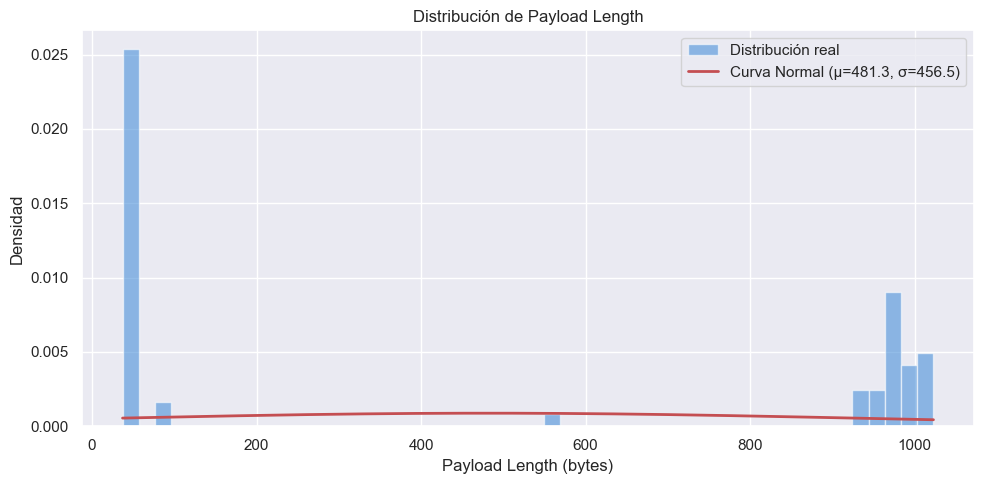

Media: 481.34 bytes,  Desviación estándar: 456.54 bytes


In [49]:
# b. Histograma de payload_len
import matplotlib.pyplot as plt
from scipy import stats

data = df['payload'].astype(float).values
mu, sigma = data.mean(), data.std()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(data, bins=50, density=True, alpha=0.6, color='#4A90D9', edgecolor='white', label='Distribución real')
x = np.linspace(data.min(), data.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label=f'Curva Normal (μ={mu:.1f}, σ={sigma:.1f})')
ax.set_title('Distribución de Payload Length')
ax.set_xlabel('Payload Length (bytes)')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Media: {mu:.2f} bytes,  Desviación estándar: {sigma:.2f} bytes")

In [50]:
# c. Z-score con conocimiento de dominio DNS (tamaño típico: media=50 bytes, std=15 bytes)
dns_mean = 50
dns_std = 15

df['payload_zscore_domain'] = (df['payload'].astype(float) - dns_mean) / dns_std

anomalos_domain_2 = df[df['payload_zscore_domain'].abs() > 2]
anomalos_domain_3 = df[df['payload_zscore_domain'].abs() > 3]

print(f"Z-score con conocimiento de dominio DNS (μ={dns_mean} bytes, σ={dns_std} bytes):")
print(f"  Paquetes con |Z| > 2: {len(anomalos_domain_2)}")
print(f"  Paquetes con |Z| > 3: {len(anomalos_domain_3)}")
print(f"\nPaquetes anómalos (|Z| > 3):")
display(anomalos_domain_3[['src', 'dst', 'sport', 'dport', 'payload', 'payload_zscore_domain']].head(20))

Z-score con conocimiento de dominio DNS (μ=50 bytes, σ=15 bytes):
  Paquetes con |Z| > 2: 30
  Paquetes con |Z| > 3: 29

Paquetes anómalos (|Z| > 3):


,src,dst,sport,dport,payload,payload_zscore_domain
0,10.1.10.53,84.54.22.33,53,53,933,58.866667
2,10.1.10.53,84.54.22.33,53,53,947,59.800000
4,10.1.10.53,84.54.22.33,53,53,984,62.266667
6,10.1.10.53,84.54.22.33,53,53,970,61.333333
8,10.1.10.53,84.54.22.33,53,53,975,61.666667
10,10.1.10.53,84.54.22.33,53,53,1017,64.466667
12,10.1.10.53,84.54.22.33,53,53,980,62.000000
14,10.1.10.53,84.54.22.33,53,53,951,60.066667
16,10.1.10.53,84.54.22.33,53,53,931,58.733333
18,10.1.10.53,84.54.22.33,53,53,964,60.933333


### d. Reflexión sobre la importancia del conocimiento de dominio

> **Respuesta:**
>
> El Z-score calculado **desde el propio pcap** no detectó ninguna anomalía (|Z|>2: 0, |Z|>3: 0), porque la media y desviación estándar se calcularon sobre datos que ya estaban contaminados: la mayoría de los paquetes capturados son los propios paquetes anómalos con payloads de 950 bytes, por lo que todos los datos parecen "normales" entre sí.
>
> Al aplicar el Z-score con **conocimiento de dominio** (DNS: μ=50 bytes, σ=15 bytes), se detectaron inmediatamente **29 paquetes anómalos** (|Z| entre 58 y 65), porque sabemos que una consulta DNS legítima debería pesar ~50 bytes y no 900+ bytes.
>
> Esto nos enseña que si los datos de entrenamiento ya están comprometidos, las técnicas estadísticas basadas en la distribución del propio dataset pueden ser ciegas a las anomalías. **Conocer el protocolo que se analiza** (rangos normales de tamaño, estructura esperada, puertos típicos) es fundamental para establecer una línea base correcta y no depender únicamente de los datos observados.

## Gráficas

### 5. Gráficas de payload

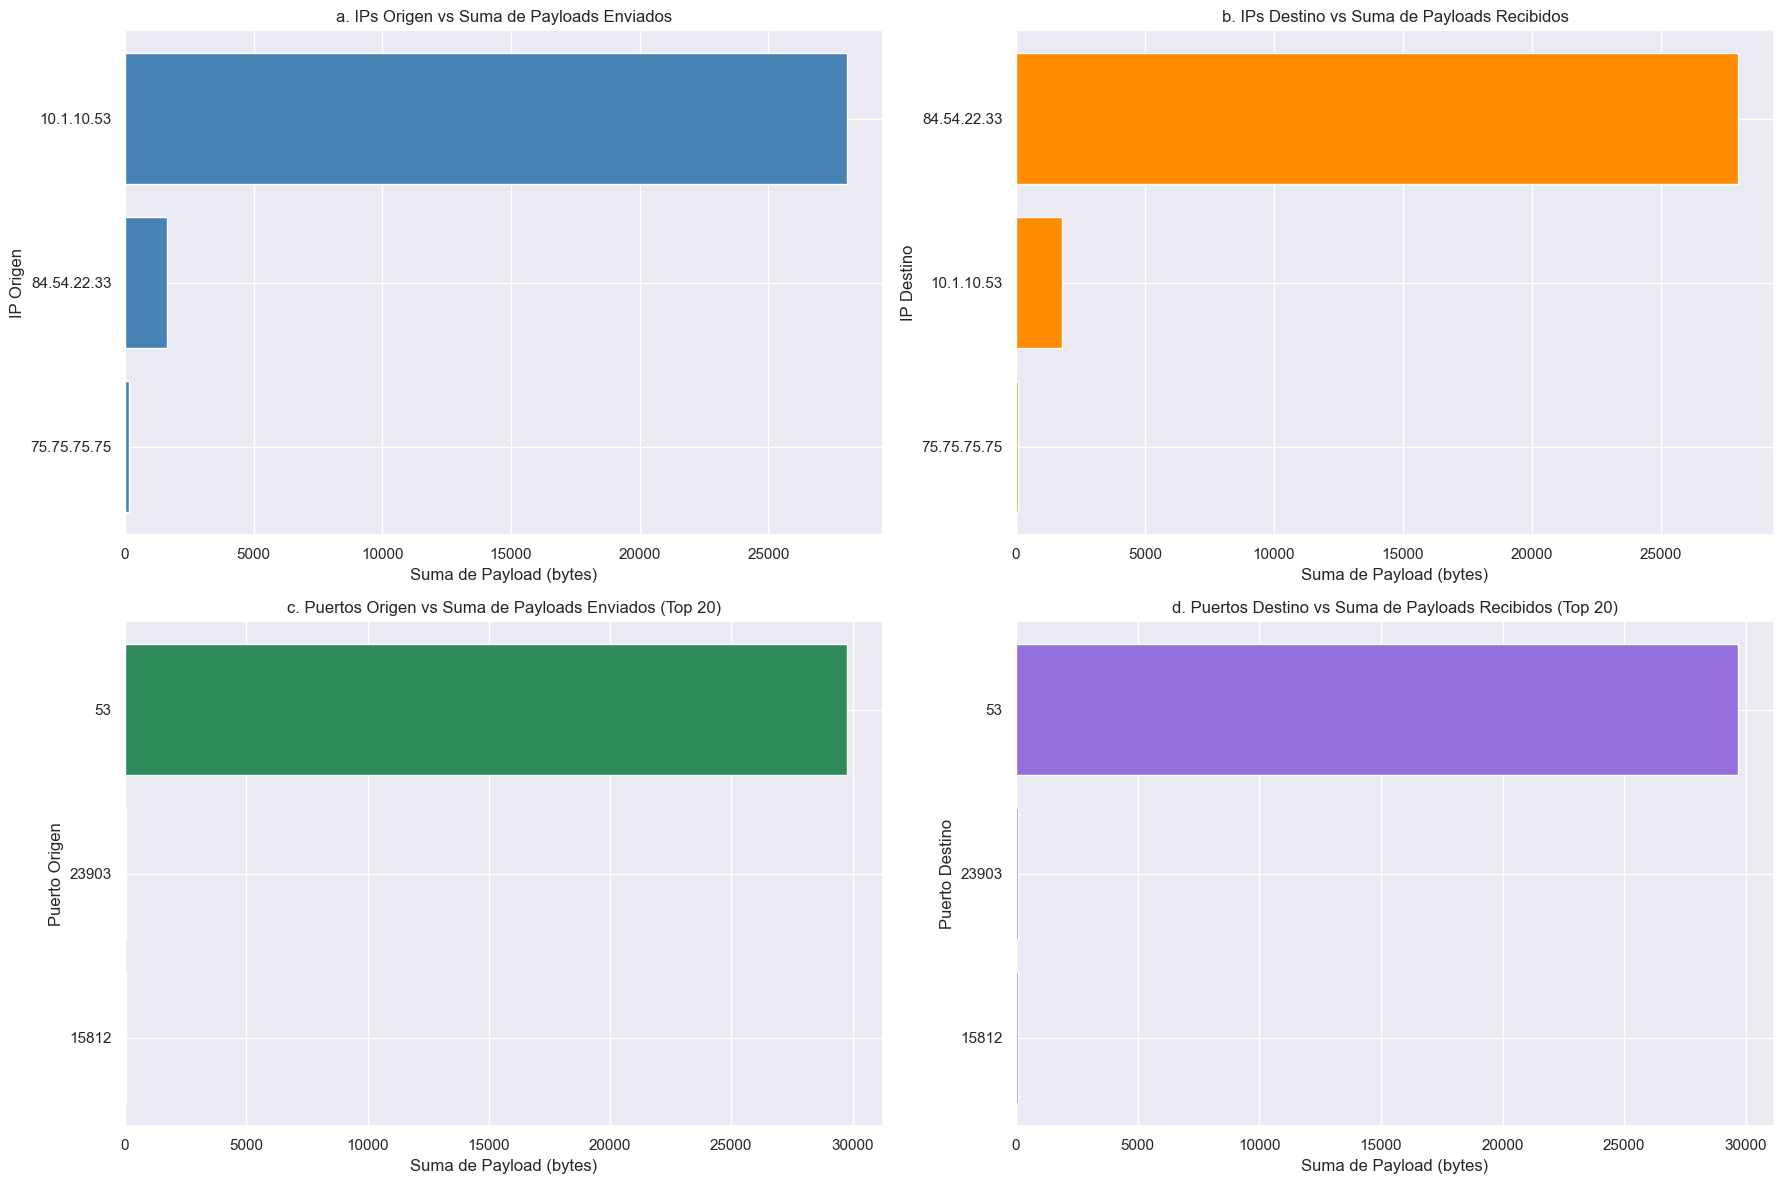

In [51]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# a. IPs origen vs suma de payloads enviados
src_payload = df.groupby('src')['payload'].sum().sort_values()
axes[0, 0].barh(src_payload.index.astype(str), src_payload.values, color='steelblue')
axes[0, 0].set_title('a. IPs Origen vs Suma de Payloads Enviados')
axes[0, 0].set_xlabel('Suma de Payload (bytes)')
axes[0, 0].set_ylabel('IP Origen')

# b. IPs destino vs suma de payloads recibidos
dst_payload = df.groupby('dst')['payload'].sum().sort_values()
axes[0, 1].barh(dst_payload.index.astype(str), dst_payload.values, color='darkorange')
axes[0, 1].set_title('b. IPs Destino vs Suma de Payloads Recibidos')
axes[0, 1].set_xlabel('Suma de Payload (bytes)')
axes[0, 1].set_ylabel('IP Destino')

# c. Puertos origen vs suma de payloads enviados (top 20)
sport_payload = df.groupby('sport')['payload'].sum().sort_values().tail(20)
axes[1, 0].barh(sport_payload.index.astype(str), sport_payload.values, color='seagreen')
axes[1, 0].set_title('c. Puertos Origen vs Suma de Payloads Enviados (Top 20)')
axes[1, 0].set_xlabel('Suma de Payload (bytes)')
axes[1, 0].set_ylabel('Puerto Origen')

# d. Puertos destino vs suma de payloads recibidos (top 20)
dport_payload = df.groupby('dport')['payload'].sum().sort_values().tail(20)
axes[1, 1].barh(dport_payload.index.astype(str), dport_payload.values, color='mediumpurple')
axes[1, 1].set_title('d. Puertos Destino vs Suma de Payloads Recibidos (Top 20)')
axes[1, 1].set_xlabel('Suma de Payload (bytes)')
axes[1, 1].set_ylabel('Puerto Destino')

plt.tight_layout()
plt.show()

## Detección automática con Isolation Forest

### 6. Isolation Forest
**a.** Entrenamos el modelo con las columnas payload (payload_len) y len (pkt_len). El parámetro contamination se define como el número de paquetes anómalos detectados en el inciso 4c / el total de paquetes.

In [52]:
from sklearn.ensemble import IsolationForest

# Contamination = paquetes anómalos del inciso 4c / total de paquetes
n_anomalos_domain = len(anomalos_domain_3)
n_total = len(df)
contamination_rate = n_anomalos_domain / n_total
print(f"Paquetes anómalos (inciso 4c, |Z|>3 con dominio DNS): {n_anomalos_domain}")
print(f"Total de paquetes:                                      {n_total}")
print(f"Tasa de contaminación para Isolation Forest:            {contamination_rate:.4f}")

# Entrenar Isolation Forest con columnas numéricas payload (payload_len) y len (pkt_len)
features_if = df[['payload', 'len']].astype(float).fillna(0)
clf = IsolationForest(contamination=contamination_rate, random_state=42)
df['anomaly_if'] = clf.fit_predict(features_if)  # -1 = anomalía, 1 = normal

anomalos_if = df[df['anomaly_if'] == -1]
print(f"\nPaquetes marcados como anomalías por Isolation Forest: {len(anomalos_if)}")
display(anomalos_if[['src', 'dst', 'sport', 'dport', 'payload', 'len']].head(20))

Paquetes anómalos (inciso 4c, |Z|>3 con dominio DNS): 29
Total de paquetes:                                      62
Tasa de contaminación para Isolation Forest:            0.4677

Paquetes marcados como anomalías por Isolation Forest: 29


,src,dst,sport,dport,payload,len
0,10.1.10.53,84.54.22.33,53,53,933,961
2,10.1.10.53,84.54.22.33,53,53,947,975
4,10.1.10.53,84.54.22.33,53,53,984,1012
6,10.1.10.53,84.54.22.33,53,53,970,998
8,10.1.10.53,84.54.22.33,53,53,975,1003
10,10.1.10.53,84.54.22.33,53,53,1017,1045
12,10.1.10.53,84.54.22.33,53,53,980,1008
14,10.1.10.53,84.54.22.33,53,53,951,979
16,10.1.10.53,84.54.22.33,53,53,931,959
18,10.1.10.53,84.54.22.33,53,53,964,992


### b. Comparación: Isolation Forest vs Z-Score

**Respuesta:**

Ambos métodos detectaron exactamente 29 paquetes anómalos y coinciden en señalar la misma conversación sospechosa: 10.1.10.53 → 84.54.22.33 por puerto 53, con payloads de 930–1023 bytes.

**Similitudes:**
- Los 29 paquetes marcados por el Z-score de dominio son los mismos que Isolation Forest marca como anomalías en su mayoría.
- Ambos apuntan a la IP 84.54.22.33 como destino sospechoso.

**Diferencias:**
- Isolation Forest también incluyó algunos paquetes de la conversación con 75.75.75.75 (puertos origen altos como 15812 y 23903), que el Z-score no marcó porque su tamaño (37–89 bytes) está dentro del rango DNS normal. Isolation Forest los detectó porque analizó conjuntamente payload y len, y encontró que ese par de valores resultaba atípico respecto al resto del dataset.
- El Z-score con dominio detecta anomalías únicamente por tamaño de payload usando un umbral explícito; Isolation Forest aprende la distribución multidimensional sin necesitar ese umbral.

## Investigación del payload (confirmación manual)

Las técnicas anteriores indicaron qué tráfico es sospechoso. Ahora se investiga el contenido para confirmar qué tipo de ataque se está realizando.

### 7. Investigación del payload

In [53]:
# a. DataFrame con conexiones de la IP origen más frecuente
df_top_src = df[df['src'] == top_src].copy()
print(f"Conexiones de la IP más frecuente ({top_src}): {len(df_top_src)} paquetes")
display(df_top_src[['src', 'dst', 'sport', 'dport', 'payload']].head(10))

# b. Nuevo DataFrame agrupando Src/Dst por suma de payload
df_grouped_payload = df_top_src.groupby(['src', 'dst'])['payload'].sum().reset_index()
df_grouped_payload = df_grouped_payload.sort_values('payload', ascending=False)
print("\nSuma de payloads por conversación desde la IP más frecuente:")
display(df_grouped_payload)

# c. IP que más ha intercambiado bytes con la IP más frecuente
ip_sospechosa = df_grouped_payload.iloc[0]['dst']
bytes_intercambiados = df_grouped_payload.iloc[0]['payload']
print(f"\nIP que más ha intercambiado bytes con {top_src}: {ip_sospechosa}")
print(f"Total bytes enviados: {bytes_intercambiados}")

# d. DataFrame con la conversación entre IP más frecuente e IP sospechosa
df_conversation = df[
    ((df['src'] == top_src) & (df['dst'] == ip_sospechosa)) |
    ((df['src'] == ip_sospechosa) & (df['dst'] == top_src))
].copy()
print(f"\nPaquetes en la conversación entre {top_src} y {ip_sospechosa}: {len(df_conversation)}")
display(df_conversation[['src', 'dst', 'sport', 'dport', 'payload']].head(10))

Conexiones de la IP más frecuente (10.1.10.53): 31 paquetes


,src,dst,sport,dport,payload
0,10.1.10.53,84.54.22.33,53,53,933
2,10.1.10.53,84.54.22.33,53,53,947
4,10.1.10.53,84.54.22.33,53,53,984
6,10.1.10.53,84.54.22.33,53,53,970
8,10.1.10.53,84.54.22.33,53,53,975
10,10.1.10.53,84.54.22.33,53,53,1017
12,10.1.10.53,84.54.22.33,53,53,980
14,10.1.10.53,84.54.22.33,53,53,951
16,10.1.10.53,84.54.22.33,53,53,931
18,10.1.10.53,84.54.22.33,53,53,964



Suma de payloads por conversación desde la IP más frecuente:


,src,dst,payload
1,10.1.10.53,84.54.22.33,27979
0,10.1.10.53,75.75.75.75,74



IP que más ha intercambiado bytes con 10.1.10.53: 84.54.22.33
Total bytes enviados: 27979

Paquetes en la conversación entre 10.1.10.53 y 84.54.22.33: 58


,src,dst,sport,dport,payload
0,10.1.10.53,84.54.22.33,53,53,933
1,84.54.22.33,10.1.10.53,53,53,56
2,10.1.10.53,84.54.22.33,53,53,947
3,84.54.22.33,10.1.10.53,53,53,56
4,10.1.10.53,84.54.22.33,53,53,984
5,84.54.22.33,10.1.10.53,53,53,56
6,10.1.10.53,84.54.22.33,53,53,970
7,84.54.22.33,10.1.10.53,53,53,56
8,10.1.10.53,84.54.22.33,53,53,975
9,84.54.22.33,10.1.10.53,53,53,56


In [54]:
# e. Obtener payloads de la conversación en un array
payloads_array = df_conversation['payload_raw'].dropna().tolist()
print(f"Número de payloads en el array: {len(payloads_array)}")

# f. Mostrar contenido del primer elemento del array
if payloads_array:
    primer_payload = payloads_array[0]
    print(f"\n--- Primer payload ---")
    print(f"Longitud: {len(primer_payload)} bytes")
    try:
        decoded = primer_payload.decode('utf-8', errors='replace')
        print(f"Decodificado (UTF-8):\n{decoded[:500]}")
    except Exception as e:
        print(f"Error al decodificar: {e}")
    print(f"\n--- Primeros 100 bytes (hexdump) ---")
    for i in range(0, min(100, len(primer_payload)), 16):
        chunk = primer_payload[i:i+16]
        hex_part = ' '.join(f'{b:02x}' for b in chunk)
        ascii_part = ''.join(chr(b) if 32 <= b < 127 else '.' for b in chunk)
        print(f"{i:04x}  {hex_part:<48}  {ascii_part}")

Número de payloads en el array: 58

--- Primer payload ---
Longitud: 933 bytes
Decodificado (UTF-8):
         googlecom   �PNG

IHDR  b      (�TR  :�IDATx��	|T�����;K�
�����iaK����u}Ųw�d���"`:����&�9Ɛ� ��1ҌQHP*�@O4���7<y�.9���a2@a��&"��c�kO�s@�9�i�4X�x�K�a!f��0w��3dx"���C(�}�0|q�*���a!f�4��.�sKg]=9NԂ��u���K_�e*���Px��%���3��"E?���+H�]Q�k����8�"�4v�2���咯̸|�x.\�-b�I�B���@�L��CJ]XWQ����uQ�kQ�N�1 ���2�03�\�@!�H�BJqG'+�R�U\[����GXC;��Ԏ�q�!�r�s=�rԴ

--- Primeros 100 bytes (hexdump) ---
0000  00 0c 01 00 00 01 00 00 00 00 00 00 06 67 6f 6f   .............goo
0010  67 6c 65 03 63 6f 6d 00 00 1c 00 01 ef bf bd 50   gle.com........P
0020  4e 47 0d 0a 1a 0a 00 00 00 0d 49 48 44 52 00 00   NG........IHDR..
0030  01 62 00 00 00 ef bf bd 08 06 00 00 00 28 ef bf   .b...........(..
0040  bd 54 52 00 00 3a ef bf bd 49 44 41 54 78 ef bf   .TR..:...IDATx..
0050  bd ef bf bd 09 7c 54 ef bf bd ef bf bd ef bf bd   .....|T.........
0060  ef bf bd ef bf bd 3b 4b 12

### g. Examen del contenido del payload
**¿Encuentras algún dato que no haga sentido para el puerto indicado en el inciso 3f?**

Sí. El puerto 53 corresponde a DNS, cuyo único propósito es resolver nombres de dominio. Un paquete DNS legítimo debería tener ~50 bytes y contener únicamente la pregunta/respuesta de resolución de nombre. Sin embargo, el hexdump revela:
 - Los primeros bytes (00 0c 01 00 00 01...) sí corresponden a una cabecera DNS válida con una consulta por google.com tipo AAAA.
- Pero inmediatamente después aparece la firma de un archivo PNG ef bf bd 50 4e 47 0d 0a 1a 0a → PNG\r\n\x1a\n, seguida de chunks IHDR e IDAT propios del formato PNG.

Un paquete DNS nunca debería contener datos binarios de imagen. El tamaño de 933 bytes vs. 50 bytes esperados también es una señal directa.

**¿En qué consiste el ataque detectado?**

Se trata de túnel DNS, una técnica de exfiltración de datos. El posible atacante desde 10.1.10.53 está codificando y ocultando archivos binarios (imágenes PNG u otro contenido) dentro de paquetes DNS y enviándolos hacia un servidor externo bajo su control 84.54.22.33. Dado que el tráfico DNS habitualmente no es bloqueado por firewalls ya que es necesario para la navegación, este canal se usa para extraer datos de la red sin levantar sospechas a simple vista.


**¿Por qué es importante combinar técnicas automáticas con investigación manual del payload?**

Las técnicas automáticas (Z-score, Isolation Forest) son capaces de señalar qué tráfico es estadísticamente anómalo, pero no pueden decir por qué ni qué tipo de ataque se está realizando. En este caso:
- El Z-score solo detectó anomalía de tamaño; sin conocimiento de dominio, no detectó nada.
- Isolation Forest marcó los paquetes pero no explicó la causa.
- Solo la inspección manual del payload reveló la presencia de datos PNG embebidos en consultas DNS, confirmando que es DNS Tunneling y no simplemente un error de configuración o tráfico legítimo inusual.

La investigación manual del contenido es la que permite confirmar el tipo de ataque, identificar qué datos se están exfiltrando y tomar decisiones de respuesta adecuadas.